# Wave Packet Ray Tracing in Cartesian Shearing Box

## Physical Setup

- **Constant shear rate**: $\sigma_s$ (background shear)
- **Coriolis parameter**: $f$ 
- **Brunt-Väisälä frequency**: $N$ (stratification)
- **Effective vorticity**: $F = f(\sigma_s + f)$

## Simplified Dispersion Relation $k_x << k_y$

$$
k_y^2 + \frac{(\Phi^2 + F) k_z^2}{\Phi^2 + N^2} = 0
$$

where $\Phi = -i(\omega + k_x \sigma_s y)$ and $\omega$ is the real frequency.

## Key Insight

With $k_x$ and $k_z$ **fixed**, the dispersion relation gives:

$$
\frac{k_y^2}{k_z^2} = -\frac{\Phi^2 + F}{\Phi^2 + N^2}
$$

For quasi-stationary waves ($\omega \approx 0$): $\Phi \approx -ik_x\sigma_s y$ (purely imaginary), so $\Phi^2 \approx -(k_x\sigma_s y)^2 < 0$

## Evanescent Region

Waves are evanescent (non-propagating) when $k_y^2 < 0$, which occurs when:

$$
-\frac{\Phi^2 + F}{\Phi^2 + N^2} < 0
$$

For $F > 0$, this gives an evanescent region: $|y| < \sqrt{F}/|k_x\sigma_s|$

## Ray Trajectory

The group velocity $\mathbf{C}_g \perp \mathbf{k}$ gives:

$$
\frac{dz}{dy} = \pm\frac{k_y}{k_z}
$$

Since $k_z$ is fixed (non-zero), we integrate along $y$ to avoid singularities when $k_y \to 0$.

**Two modes** correspond to the **two signs** of $dz/dy$:
- **Mode 1**: $dz/dy = +k_y/k_z$ 
- **Mode 2**: $dz/dy = -k_y/k_z$

For each mode, we integrate in both $\pm y$ directions from the starting point to obtain the **complete trajectory**.

Critical layers at $y_c = \pm N/(|k_x\sigma_s|)$ are approached but never reached.

## 1. Dispersion Relation and Ray Equations

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
class CartesianShearingBoxRays:
    """
    Ray tracing for inertia-gravity waves in shearing box.
    
    Fixed: kx, kz
    Variable: ky(y), determined by dispersion relation
    """
    
    def __init__(self, N, f, sigma_s, kx, Lx):
        """
        Parameters:
        -----------
        N : float
            Brunt-Väisälä frequency
        f : float
            Coriolis parameter
        sigma_s : float
            Shear rate (negative for cyclonic)
        kx : float
            Fixed streamwise wavenumber
        Lx : float
            Domain size for normalization
        """
        self.N = N
        self.f = f
        self.sigma_s = sigma_s
        self.F = f * (sigma_s + f)
        self.kx = kx
        self.Lx = Lx
        
        print(f"Shearing Box Ray Tracer Initialized:")
        print(f"  N = {N}, f = {f}, σ_s = {sigma_s}")
        print(f"  F = f(σ_s + f) = {self.F}")
        print(f"  kx = {kx} (fixed)")
        
        # Calculate critical layer location (where omega = 0)
        if kx != 0:
            self.y_crit = N / (abs(kx * sigma_s))
            print(f"  Critical layers at y = ±{self.y_crit:.4f}")
        else:
            self.y_crit = np.inf
        
        # Calculate evanescent region boundaries
        # For quasi-stationary waves (omega ~ 0), ky^2 < 0 when:
        # -(Phi^2 + F)/(Phi^2 + N^2) < 0
        # This occurs when Phi^2 + F > 0 and Phi^2 + N^2 > 0
        # or when Phi^2 + F < 0 and Phi^2 + N^2 < 0
        # With Phi^2 = -(kx*sigma_s*y)^2, we have Phi^2 < 0
        # So: -(kx*sigma_s*y)^2 + F > 0 requires F > 0 (not our case)
        # And: -(kx*sigma_s*y)^2 + F < 0 AND -(kx*sigma_s*y)^2 + N^2 < 0
        # The second gives: (kx*sigma_s*y)^2 > N^2, i.e., |y| > N/|kx*sigma_s|
        # The first gives: (kx*sigma_s*y)^2 > F, i.e., |y| > sqrt(F)/|kx*sigma_s|
        
        if self.F > 0 and kx != 0:
            self.y_evan_limit = np.sqrt(self.F) / abs(kx * sigma_s)
            print(f"  Evanescent region for |y| < {self.y_evan_limit:.4f}")
        else:
            self.y_evan_limit = 0.0
            print(f"  No evanescent region (F = {self.F} <= 0)")
    
    def compute_ky(self, y, kz):
        """
        Compute ky from dispersion relation at position y.
        
        From: ky^2/kz^2 = -(Phi^2 + F)/(Phi^2 + N^2)
        where Phi = -i*(omega + kx*sigma_s*y)
        
        Near critical layer (omega ~ 0):
        Phi ≈ -i*kx*sigma_s*y, so Phi^2 ≈ -(kx*sigma_s*y)^2
        
        Returns:
        --------
        ky : float or None
            Magnitude of ky (positive). Returns None if evanescent.
        """
        # Approximate Phi^2 (assumes omega small near critical layer)
        Phi_squared = -(self.kx * self.sigma_s * y)**2
        
        # ky^2/kz^2 = -(Phi^2 + F)/(Phi^2 + N^2)
        numerator = Phi_squared + self.F
        denominator = Phi_squared + self.N**2
        
        if abs(denominator) < 1e-10:
            return None  # Singular point
        
        ratio = -numerator / denominator
        
        if ratio < 0:
            return None  # Evanescent (ky imaginary)
        
        # Return magnitude only
        ky_mag = np.sqrt(ratio) * abs(kz)
        
        return ky_mag
    
    def compute_dzdy(self, y, kz, sign_choice=+1):
        """
        Compute dz/dy from group velocity perpendicular to wavevector.
        
        Since C_g ⊥ k, we have: dz/dy = ±ky/kz
        
        Parameters:
        -----------
        y : float
            Current y position
        kz : float
            Fixed vertical wavenumber
        sign_choice : +1 or -1
            Choose which branch: +ky/kz or -ky/kz
        
        This avoids division by zero when ky → 0.
        """
        ky = self.compute_ky(y, kz)
        
        if ky is None:
            return None  # Evanescent region
        
        return sign_choice * ky / kz
    
    def trace_ray(self, y0, z0, kz, sign_choice=+1, dy=0.01, max_steps=10000):
        """
        Trace complete ray trajectory by integrating in both directions from (y0, z0).
        
        Parameters:
        -----------
        y0, z0 : float
            Starting position
        kz : float
            Fixed vertical wavenumber
        sign_choice : +1 or -1
            Choose branch: +ky/kz or -ky/kz
        dy : float
            Integration step in y
        max_steps : int
            Maximum number of steps in each direction
            
        Returns:
        --------
        y_array, z_array : arrays
            Complete ray trajectory (both directions from starting point)
        """
        # Integrate in positive y direction
        y_pos_list = [y0]
        z_pos_list = [z0]
        y_current = y0
        z_current = z0
        
        for step in range(max_steps):
            dzdy = self.compute_dzdy(y_current, kz, sign_choice)
            
            if dzdy is None:
                break  # Hit evanescent region
            
            # Check boundaries
            if abs(y_current) > 0.995 * self.y_crit:
                break  # Near critical layer
            
            # Step in +y direction
            y_current += dy
            z_current += dzdy * dy
            
            y_pos_list.append(y_current)
            z_pos_list.append(z_current)
            
            if abs(y_current) > self.Lx or abs(z_current) > self.Lx:
                break
        
        # Integrate in negative y direction
        y_neg_list = []
        z_neg_list = []
        y_current = y0
        z_current = z0
        
        for step in range(max_steps):
            dzdy = self.compute_dzdy(y_current, kz, sign_choice)
            
            if dzdy is None:
                break  # Hit evanescent region
            
            # Check boundaries
            if abs(y_current) > 0.995 * self.y_crit:
                break  # Near critical layer
            
            # Step in -y direction
            y_current -= dy
            z_current -= dzdy * dy
            
            y_neg_list.append(y_current)
            z_neg_list.append(z_current)
            
            if abs(y_current) > self.Lx or abs(z_current) > self.Lx:
                break
        
        # Combine: reverse negative direction, then add positive direction
        y_neg_list.reverse()
        z_neg_list.reverse()
        y_array = np.array(y_neg_list + y_pos_list)
        z_array = np.array(z_neg_list + z_pos_list)
        
        return y_array, z_array

## 2. Background Parameters

In [3]:
# Physical parameters
N = 2.0
f = 1.0
sigma_s = 1.5

## 3. Trace Single Ray (Both Modes)

Shearing Box Ray Tracer Initialized:
  N = 2.0, f = 1.0, σ_s = 1.5
  F = f(σ_s + f) = 2.5
  kx = 0.6283185307179586 (fixed)
  Critical layers at y = ±2.1221
  Evanescent region for |y| < 1.6776
Starting point: y0 = 1.6876 (evanescent limit: 1.6776), z0 = 0.0000
Mode 1 (+ky/kz): 46 points, y ∈ [1.668, 2.118], z ∈ [-0.001, 0.536]
Mode 2 (-ky/kz): 46 points, y ∈ [1.668, 2.118], z ∈ [-0.536, 0.001]


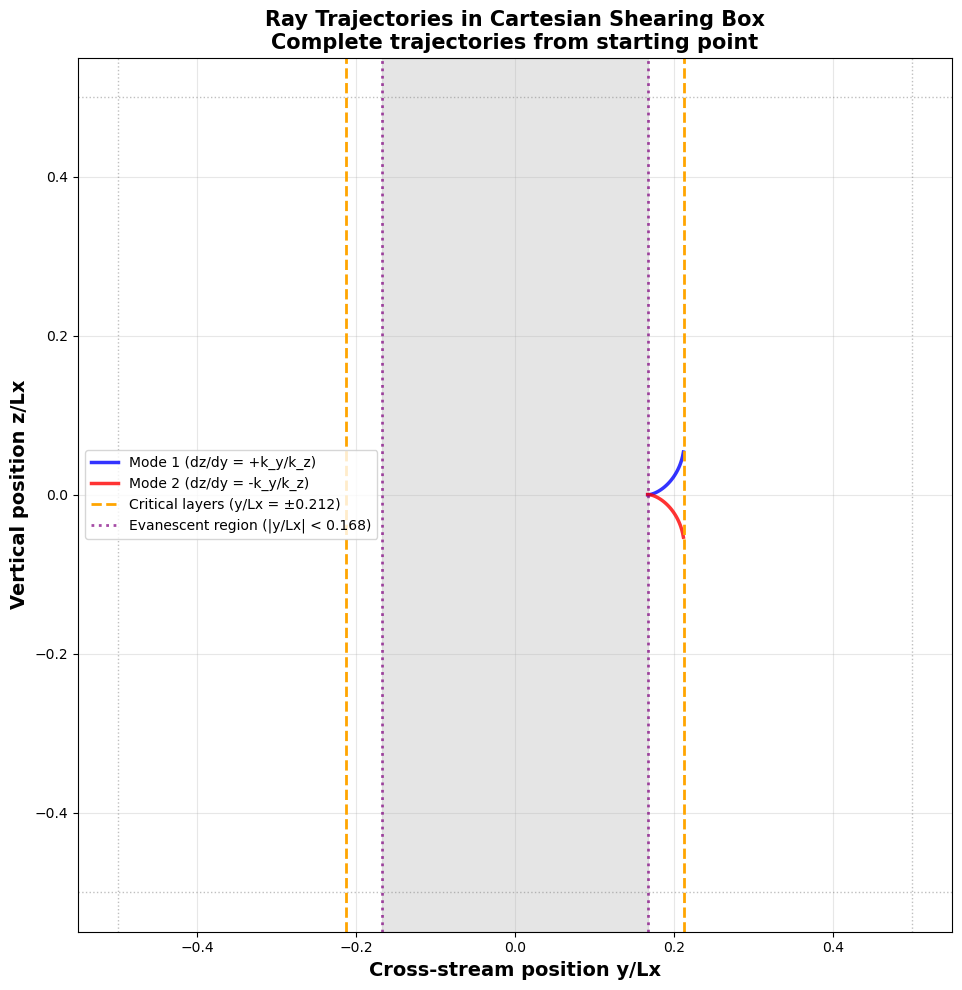

In [4]:
# Set parameters and construct tracer
Lx = 10.0
nx = 1.0
kx = 2 * np.pi * nx / Lx
nz = 1.0
kz = 2 * np.pi * nz / Lx
tracer = CartesianShearingBoxRays(N, f, sigma_s, kx, Lx)

# Starting point - just outside evanescent region at z = 0
if tracer.y_evan_limit > 0:
    y0 = tracer.y_evan_limit + 0.01  # Start just outside evanescent boundary
else:
    y0 = 0.01  # No evanescent region, start near origin
z0 = 0.0

print(f"Starting point: y0 = {y0:.4f} (evanescent limit: {tracer.y_evan_limit:.4f}), z0 = {z0:.4f}")

# Mode 1: dz/dy = +ky/kz
y1, z1 = tracer.trace_ray(y0, z0, kz=kz, sign_choice=+1, dy=0.01)

# Mode 2: dz/dy = -ky/kz
y2, z2 = tracer.trace_ray(y0, z0, kz=kz, sign_choice=-1, dy=0.01)

print(f"Mode 1 (+ky/kz): {len(z1)} points, y ∈ [{y1.min():.3f}, {y1.max():.3f}], z ∈ [{z1.min():.3f}, {z1.max():.3f}]")
print(f"Mode 2 (-ky/kz): {len(z2)} points, y ∈ [{y2.min():.3f}, {y2.max():.3f}], z ∈ [{z2.min():.3f}, {z2.max():.3f}]")

fig, ax = plt.subplots(figsize=(10, 10))

# Plot trajectories (normalized)
ax.plot(y1/Lx, z1/Lx, 'b-', linewidth=2.5, label='Mode 1 (dz/dy = +k_y/k_z)', alpha=0.8)
ax.plot(y2/Lx, z2/Lx, 'r-', linewidth=2.5, label='Mode 2 (dz/dy = -k_y/k_z)', alpha=0.8)

# Critical layers
y_c = tracer.y_crit
ax.axvline(y_c/Lx, color='orange', linestyle='--', linewidth=2, 
           label=f'Critical layers (y/Lx = ±{y_c/Lx:.3f})')
ax.axvline(-y_c/Lx, color='orange', linestyle='--', linewidth=2)

# Evanescent region (if exists)
if tracer.y_evan_limit > 0:
    y_ev = tracer.y_evan_limit
    ax.axvline(y_ev/Lx, color='purple', linestyle=':', linewidth=2, alpha=0.7,
               label=f'Evanescent region (|y/Lx| < {y_ev/Lx:.3f})')
    ax.axvline(-y_ev/Lx, color='purple', linestyle=':', linewidth=2, alpha=0.7)
    ax.axvspan(-y_ev/Lx, y_ev/Lx, color='gray', alpha=0.2, zorder=0)

# Domain boundaries
ax.axvline(-0.5, color='gray', linestyle=':', linewidth=1, alpha=0.5)
ax.axvline(0.5, color='gray', linestyle=':', linewidth=1, alpha=0.5)
ax.axhline(-0.5, color='gray', linestyle=':', linewidth=1, alpha=0.5)
ax.axhline(0.5, color='gray', linestyle=':', linewidth=1, alpha=0.5)

# Formatting
ax.set_xlabel('Cross-stream position y/Lx', fontsize=14, fontweight='bold')
ax.set_ylabel('Vertical position z/Lx', fontsize=14, fontweight='bold')
ax.set_title('Ray Trajectories in Cartesian Shearing Box\n'
             'Complete trajectories from starting point', 
             fontsize=15, fontweight='bold')
ax.legend(fontsize=10, loc='best')
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')
ax.set_xlim(-0.55, 0.55)
ax.set_ylim(-0.55, 0.55)

plt.tight_layout()
plt.show()

## 4. St. Andrew's Cross Pattern

Trace multiple rays with different streamwise wavenumbers $n_x$. Each $n_x$ produces different critical layer locations and trajectory shapes. Both modes (both signs of $dz/dy$) are shown for each $n_x$.

Shearing Box Ray Tracer Initialized:
  N = 2.0, f = 1.0, σ_s = 1.5
  F = f(σ_s + f) = 2.5
  kx = 0.6283185307179586 (fixed)
  Critical layers at y = ±2.1221
  Evanescent region for |y| < 1.6776
nx = 1: y_crit = 2.1221, y_evan = 1.6776, Mode 1 has 46 points, Mode 2 has 46 points
Shearing Box Ray Tracer Initialized:
  N = 2.0, f = 1.0, σ_s = 1.5
  F = f(σ_s + f) = 2.5
  kx = 1.2566370614359172 (fixed)
  Critical layers at y = ±1.0610
  Evanescent region for |y| < 0.8388
nx = 2: y_crit = 1.0610, y_evan = 0.8388, Mode 1 has 24 points, Mode 2 has 24 points
Shearing Box Ray Tracer Initialized:
  N = 2.0, f = 1.0, σ_s = 1.5
  F = f(σ_s + f) = 2.5
  kx = 1.8849555921538759 (fixed)
  Critical layers at y = ±0.7074
  Evanescent region for |y| < 0.5592
nx = 3: y_crit = 0.7074, y_evan = 0.5592, Mode 1 has 17 points, Mode 2 has 17 points
Shearing Box Ray Tracer Initialized:
  N = 2.0, f = 1.0, σ_s = 1.5
  F = f(σ_s + f) = 2.5
  kx = 2.5132741228718345 (fixed)
  Critical layers at y = ±0.5305
  Evan

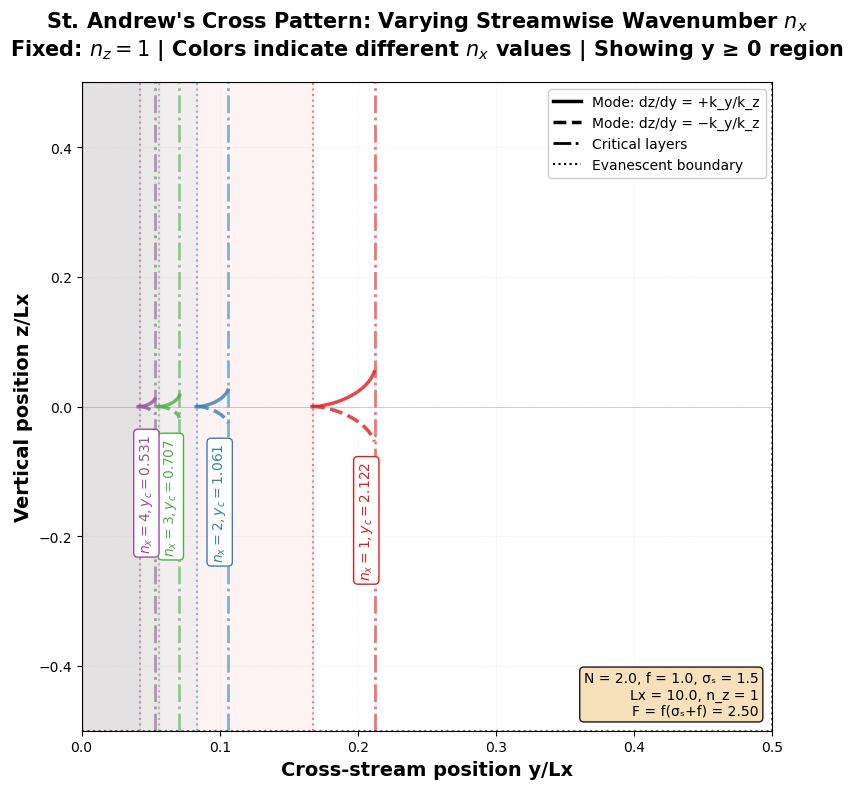

In [ ]:
# Physical parameters
N = 2.0
f = 1.0
sigma_s = 1.5

# Different nx values (integer wave indices), fixed nz = 1
Lx = 10.0
nx_values = [1, 2, 3, 4]
nz_fixed = 1

trajectories_pos = []  # dz/dy = +ky/kz
trajectories_neg = []  # dz/dy = -ky/kz
critical_layers = []   # Critical layer positions for each nx
evanescent_limits = [] # Evanescent region limits for each nx
starting_points = []   # Starting points for each nx

for nx in nx_values:
    kx_val = 2 * np.pi * nx / Lx
    kz_val = 2 * np.pi * nz_fixed / Lx
    
    # Create temporary tracer for this nx
    temp_tracer = CartesianShearingBoxRays(N, f, sigma_s, kx_val, Lx)
    
    # Starting point - just outside evanescent region at z = 0
    if temp_tracer.y_evan_limit > 0:
        y_start = temp_tracer.y_evan_limit + 0.01
    else:
        y_start = 0.01
    z_start = 0.0
    
    # Mode 1: dz/dy = +ky/kz
    y_pos, z_pos = temp_tracer.trace_ray(y_start, z_start, kz=kz_val, sign_choice=+1, dy=0.01)
    trajectories_pos.append({'y': y_pos, 'z': z_pos, 'nx': nx})
    
    # Mode 2: dz/dy = -ky/kz
    y_neg, z_neg = temp_tracer.trace_ray(y_start, z_start, kz=kz_val, sign_choice=-1, dy=0.01)
    trajectories_neg.append({'y': y_neg, 'z': z_neg, 'nx': nx})
    
    # Store critical layers, evanescent limits, and starting points
    critical_layers.append(temp_tracer.y_crit)
    evanescent_limits.append(temp_tracer.y_evan_limit)
    starting_points.append((y_start, z_start))
    
    print(f"nx = {nx}: y_crit = {temp_tracer.y_crit:.4f}, y_evan = {temp_tracer.y_evan_limit:.4f}, "
          f"Mode 1 has {len(z_pos)} points, Mode 2 has {len(z_neg)} points")
    
fig, ax = plt.subplots(figsize=(8, 8))

colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3']

# Plot trajectories for each nx
for i, (traj_pos, traj_neg) in enumerate(zip(trajectories_pos, trajectories_neg)):
    nx_val = traj_pos['nx']
    color = colors[i]
    
    # Mode 1: solid line
    ax.plot(traj_pos['y']/Lx, traj_pos['z']/Lx, color=color, linestyle='-', 
            linewidth=2.5, alpha=0.8)
    
    # Mode 2: dashed line
    ax.plot(traj_neg['y']/Lx, traj_neg['z']/Lx, color=color, linestyle='--', 
            linewidth=2.5, alpha=0.8)
    
    # Critical layers with same color (only positive side for cleaner plot)
    y_c = critical_layers[i]
    ax.axvline(y_c/Lx, color=color, linestyle='-.', linewidth=2, alpha=0.6, zorder=1)
    
    # Add text label near critical layer with nx and yc value
    ax.text(y_c/Lx, np.min(traj_neg['z'])/Lx-0.03, f'$n_x={nx_val}, y_c={y_c:.3f}$', fontsize=10, 
            color=color, fontweight='bold', rotation=90, 
            verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor=color, alpha=1.0))
    
    # Evanescent region boundaries with same color (only positive side)
    if evanescent_limits[i] > 0:
        y_ev = evanescent_limits[i]
        ax.axvline(y_ev/Lx, color=color, linestyle=':', linewidth=1.5, alpha=0.5, zorder=1)
        # Light shading for evanescent region
        ax.axvspan(0, y_ev/Lx, color=color, alpha=0.05, zorder=0)

# Domain boundaries
ax.axvline(0.5, color='black', linestyle=':', linewidth=1.5, alpha=0.6)
ax.axhline(-0.5, color='black', linestyle=':', linewidth=1.5, alpha=0.6)
ax.axhline(0.5, color='black', linestyle=':', linewidth=1.5, alpha=0.6)

# Axis at y=0 (left boundary)
ax.axvline(0, color='black', linestyle='-', linewidth=1.5, alpha=0.8)
ax.axhline(0, color='gray', linestyle='-', linewidth=0.5, alpha=0.5)

# Legend - show line styles only (in black)
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='black', linewidth=2.5, linestyle='-', label='Mode: dz/dy = +k_y/k_z'),
    Line2D([0], [0], color='black', linewidth=2.5, linestyle='--', label='Mode: dz/dy = −k_y/k_z'),
    Line2D([0], [0], color='black', linewidth=2, linestyle='-.', label='Critical layers'),
    Line2D([0], [0], color='black', linewidth=1.5, linestyle=':', label='Evanescent boundary')
]
ax.legend(handles=legend_elements, fontsize=10, loc='upper right', framealpha=1.0)

# Formatting
ax.set_xlabel('Cross-stream position y/Lx', fontsize=14, fontweight='bold')
ax.set_ylabel('Vertical position z/Lx', fontsize=14, fontweight='bold')
ax.set_title("St. Andrew's Cross Pattern: Varying Streamwise Wavenumber $n_x$\n"
             f"Fixed: $n_z = {nz_fixed}$ | Colors indicate different $n_x$ values | Showing y ≥ 0 region", fontsize=15, fontweight='bold', pad=20)
ax.grid(True, alpha=0.3, linestyle=':', linewidth=0.5)
ax.set_xlim( 0.0, 0.5)
ax.set_ylim(-0.5, 0.5)

# Parameter text
param_text = f'N = {N}, f = {f}, σₛ = {sigma_s}\nLx = {Lx}, n_z = {nz_fixed}\nF = f(σₛ+f) = {tracer.F:.2f}'
ax.text(0.98, 0.02, param_text, transform=ax.transAxes, 
        fontsize=10, verticalalignment='bottom', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.9))

plt.tight_layout()
plt.show()

Shearing Box Ray Tracer Initialized:
  N = 1.5, f = 1.0, σ_s = -0.9
  F = f(σ_s + f) = 0.09999999999999998
  kx = 0.6283185307179586 (fixed)
  Critical layers at y = ±2.6526
  Evanescent region for |y| < 0.5592
nx = 1: y_crit = 2.6526, y_evan = 0.5592, Mode 1 has 210 points, Mode 2 has 210 points
Shearing Box Ray Tracer Initialized:
  N = 1.5, f = 1.0, σ_s = -0.9
  F = f(σ_s + f) = 0.09999999999999998
  kx = 1.2566370614359172 (fixed)
  Critical layers at y = ±1.3263
  Evanescent region for |y| < 0.2796
nx = 2: y_crit = 1.3263, y_evan = 0.2796, Mode 1 has 106 points, Mode 2 has 106 points
Shearing Box Ray Tracer Initialized:
  N = 1.5, f = 1.0, σ_s = -0.9
  F = f(σ_s + f) = 0.09999999999999998
  kx = 1.8849555921538759 (fixed)
  Critical layers at y = ±0.8842
  Evanescent region for |y| < 0.1864
nx = 3: y_crit = 0.8842, y_evan = 0.1864, Mode 1 has 71 points, Mode 2 has 71 points
Shearing Box Ray Tracer Initialized:
  N = 1.5, f = 1.0, σ_s = -0.9
  F = f(σ_s + f) = 0.09999999999999998
 

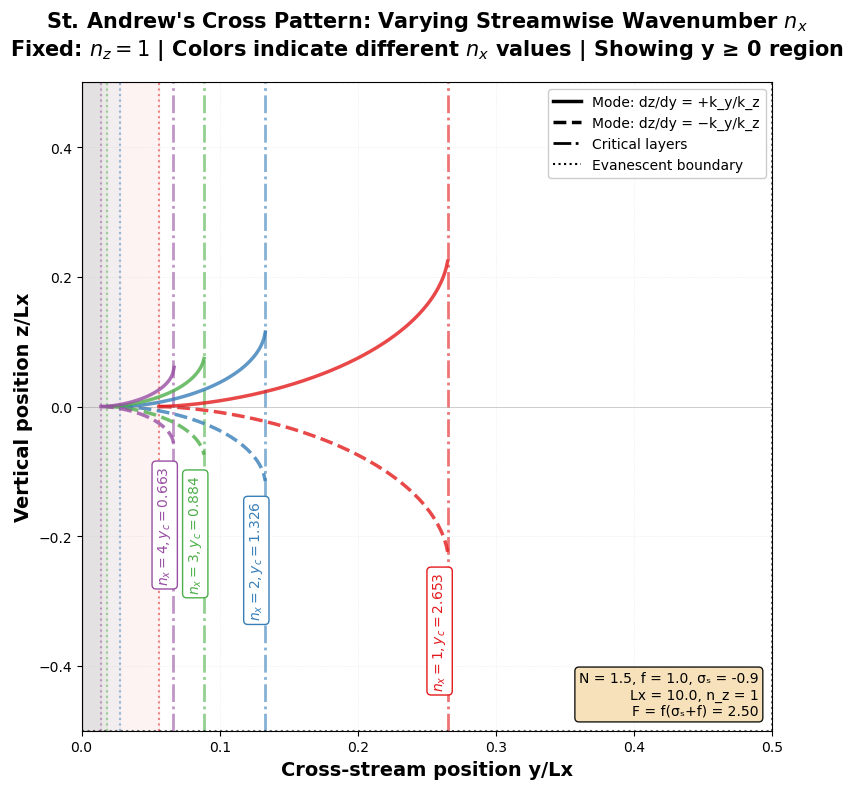

In [6]:
# Physical parameters
N = 1.5
f = 1.0
sigma_s = -0.9

# Different nx values (integer wave indices), fixed nz = 1
Lx = 10.0
nx_values = [1, 2, 3, 4]
nz_fixed = 1

trajectories_pos = []  # dz/dy = +ky/kz
trajectories_neg = []  # dz/dy = -ky/kz
critical_layers = []   # Critical layer positions for each nx
evanescent_limits = [] # Evanescent region limits for each nx
starting_points = []   # Starting points for each nx

for nx in nx_values:
    kx_val = 2 * np.pi * nx / Lx
    kz_val = 2 * np.pi * nz_fixed / Lx
    
    # Create temporary tracer for this nx
    temp_tracer = CartesianShearingBoxRays(N, f, sigma_s, kx_val, Lx)
    
    # Starting point - just outside evanescent region at z = 0
    if temp_tracer.y_evan_limit > 0:
        y_start = temp_tracer.y_evan_limit + 0.01
    else:
        y_start = 0.01
    z_start = 0.0
    
    # Mode 1: dz/dy = +ky/kz
    y_pos, z_pos = temp_tracer.trace_ray(y_start, z_start, kz=kz_val, sign_choice=+1, dy=0.01)
    trajectories_pos.append({'y': y_pos, 'z': z_pos, 'nx': nx})
    
    # Mode 2: dz/dy = -ky/kz
    y_neg, z_neg = temp_tracer.trace_ray(y_start, z_start, kz=kz_val, sign_choice=-1, dy=0.01)
    trajectories_neg.append({'y': y_neg, 'z': z_neg, 'nx': nx})
    
    # Store critical layers, evanescent limits, and starting points
    critical_layers.append(temp_tracer.y_crit)
    evanescent_limits.append(temp_tracer.y_evan_limit)
    starting_points.append((y_start, z_start))
    
    print(f"nx = {nx}: y_crit = {temp_tracer.y_crit:.4f}, y_evan = {temp_tracer.y_evan_limit:.4f}, "
          f"Mode 1 has {len(z_pos)} points, Mode 2 has {len(z_neg)} points")
    
fig, ax = plt.subplots(figsize=(8, 8))

colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3']

# Plot trajectories for each nx
for i, (traj_pos, traj_neg) in enumerate(zip(trajectories_pos, trajectories_neg)):
    nx_val = traj_pos['nx']
    color = colors[i]
    
    # Mode 1: solid line
    ax.plot(traj_pos['y']/Lx, traj_pos['z']/Lx, color=color, linestyle='-', 
            linewidth=2.5, alpha=0.8)
    
    # Mode 2: dashed line
    ax.plot(traj_neg['y']/Lx, traj_neg['z']/Lx, color=color, linestyle='--', 
            linewidth=2.5, alpha=0.8)
    
    # Critical layers with same color (only positive side for cleaner plot)
    y_c = critical_layers[i]
    ax.axvline(y_c/Lx, color=color, linestyle='-.', linewidth=2, alpha=0.6, zorder=1)
    
    # Add text label near critical layer with nx and yc value
    ax.text(y_c/Lx, np.min(traj_neg['z'])/Lx-0.03, f'$n_x={nx_val}, y_c={y_c:.3f}$', fontsize=10, 
            color=color, fontweight='bold', rotation=90, 
            verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor=color, alpha=1.0))
    
    # Evanescent region boundaries with same color (only positive side)
    if evanescent_limits[i] > 0:
        y_ev = evanescent_limits[i]
        ax.axvline(y_ev/Lx, color=color, linestyle=':', linewidth=1.5, alpha=0.5, zorder=1)
        # Light shading for evanescent region
        ax.axvspan(0, y_ev/Lx, color=color, alpha=0.05, zorder=0)

# Domain boundaries
ax.axvline(0.5, color='black', linestyle=':', linewidth=1.5, alpha=0.6)
ax.axhline(-0.5, color='black', linestyle=':', linewidth=1.5, alpha=0.6)
ax.axhline(0.5, color='black', linestyle=':', linewidth=1.5, alpha=0.6)

# Axis at y=0 (left boundary)
ax.axvline(0, color='black', linestyle='-', linewidth=1.5, alpha=0.8)
ax.axhline(0, color='gray', linestyle='-', linewidth=0.5, alpha=0.5)

# Legend - show line styles only (in black)
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='black', linewidth=2.5, linestyle='-', label='Mode: dz/dy = +k_y/k_z'),
    Line2D([0], [0], color='black', linewidth=2.5, linestyle='--', label='Mode: dz/dy = −k_y/k_z'),
    Line2D([0], [0], color='black', linewidth=2, linestyle='-.', label='Critical layers'),
    Line2D([0], [0], color='black', linewidth=1.5, linestyle=':', label='Evanescent boundary')
]
ax.legend(handles=legend_elements, fontsize=10, loc='upper right', framealpha=1.0)

# Formatting
ax.set_xlabel('Cross-stream position y/Lx', fontsize=14, fontweight='bold')
ax.set_ylabel('Vertical position z/Lx', fontsize=14, fontweight='bold')
ax.set_title("St. Andrew's Cross Pattern: Varying Streamwise Wavenumber $n_x$\n"
             f"Fixed: $n_z = {nz_fixed}$ | Colors indicate different $n_x$ values | Showing y ≥ 0 region", fontsize=15, fontweight='bold', pad=20)
ax.grid(True, alpha=0.3, linestyle=':', linewidth=0.5)
ax.set_xlim( 0.0, 0.5)
ax.set_ylim(-0.5, 0.5)

# Parameter text
param_text = f'N = {N}, f = {f}, σₛ = {sigma_s}\nLx = {Lx}, n_z = {nz_fixed}\nF = f(σₛ+f) = {tracer.F:.2f}'
ax.text(0.98, 0.02, param_text, transform=ax.transAxes, 
        fontsize=10, verticalalignment='bottom', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.9))

plt.tight_layout()
plt.show()